In [1]:
# --- Глава 3. Моделирование и прогнозирование доли инвестиций в ВВП ---

# 3.1 Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Настройки вывода
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print("Библиотеки успешно импортированы.")


Библиотеки успешно импортированы.


In [ ]:
invest_gdp = pd.read_csv("sdmx_data_1340.csv")
invest_gdp.head()

,Code,Klassifikator,Klassifikator_ru,Klassifikator_en,Klassifikator_uzc,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1700,O‘zbekiston Respublikasi,Республика Узбекистан,Republic of Uzbekistan,Ўзбекистон Республикаси,22.90,26.80,20.50,20.10,21.40,19.90,19.10,20.90,24.50,25.40,20.90,18.90,19.20,19.90,20.20,20.20,20.10,20.20,26.20,32.90,31.50,29.20,26.70,29.60,34.90


In [3]:
# создаем копию исходных данных
invest_gdp_clean = invest_gdp.copy()

# удаляем лишние столбцы ТОЛЬКО в копии
invest_gdp_clean = invest_gdp_clean.drop(columns=['Klassifikator', 'Klassifikator_uzc'])


In [10]:
# Преобразуем данные из широкого формата в длинный
df_long = invest_gdp_clean.melt(
    id_vars=invest_gdp_clean.columns[:3],  
    var_name='Year',                       
    value_name='Investment_share_GDP'      
)

# Преобразуем тип года из строкового в числовой
df_long['Year'] = df_long['Year'].astype(int)

# Проверим результат
df_long


,Code,Klassifikator_ru,Klassifikator_en,Year,Investment_share_GDP
0,1700,Республика Узбекистан,Republic of Uzbekistan,2000,22.90
1,1700,Республика Узбекистан,Republic of Uzbekistan,2001,26.80
2,1700,Республика Узбекистан,Republic of Uzbekistan,2002,20.50
3,1700,Республика Узбекистан,Republic of Uzbekistan,2003,20.10
4,1700,Республика Узбекистан,Republic of Uzbekistan,2004,21.40
5,1700,Республика Узбекистан,Republic of Uzbekistan,2005,19.90
6,1700,Республика Узбекистан,Republic of Uzbekistan,2006,19.10
7,1700,Республика Узбекистан,Republic of Uzbekistan,2007,20.90
8,1700,Республика Узбекистан,Republic of Uzbekistan,2008,24.50
9,1700,Республика Узбекистан,Republic of Uzbekistan,2009,25.40


Разделяем данные на тестовые и тренировочные

In [5]:
X = df_long[['Year']]   # вход — год
y = df_long['Investment_share_GDP']    # выход — доля инвестиций


In [6]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (20, 1) (20,)
Test: (5, 1) (5,)


1 - модель : Линйеная регрессия

In [13]:
from sklearn.linear_model import LinearRegression

# Создаем модель
model_lr = LinearRegression()

# Обучаем модель на обучающих данных
model_lr.fit(X_train, y_train)

# Делаем прогноз на тестовой выборке
y_pred_lr = model_lr.predict(X_test)

# Посмотрим первые предсказания
print("Прогноз (y_pred_lr):", y_pred_lr)


Прогноз (y_pred_lr): [23.12       23.22571429 23.33142857 23.43714286 23.54285714]


In [12]:
# Создаём DataFrame с результатами прогноза
forecast_df = pd.DataFrame({
    'Year': X_test.values.flatten(),
    'Previous_Investment_share_GDP': y_test.values.flatten(),
    'Predicted_Investment_share_GDP': y_pred_lr
})

# Округлим значения до 2 знаков
forecast_df['Predicted_Investment_share_GDP'] = forecast_df['Predicted_Investment_share_GDP'].round(2)

# Выведем таблицу
forecast_df


,Year,Previous_Investment_share_GDP,Predicted_Investment_share_GDP
0,2020,31.50,23.12
1,2021,29.20,23.23
2,2022,26.70,23.33
3,2023,29.60,23.44
4,2024,34.90,23.54


создаем график для визуального сравнения прогноза и фактических значений

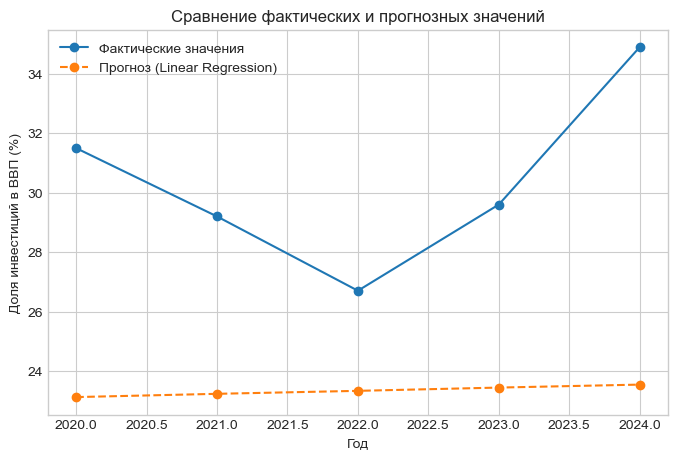

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(forecast_df['Year'], forecast_df['Previous_Investment_share_GDP'], marker='o', label='Фактические значения')
plt.plot(forecast_df['Year'], forecast_df['Predicted_Investment_share_GDP'], marker='o', linestyle='--', label='Прогноз (Linear Regression)')

plt.title('Сравнение фактических и прогнозных значений')
plt.xlabel('Год')
plt.ylabel('Доля инвестиций в ВВП (%)')
plt.legend()
plt.grid(True)
plt.show()


2 - модель : Ridge/Lasso

In [15]:
from sklearn.linear_model import Ridge

# Создаем модель Ridge с параметром регуляризации alpha
model_ridge = Ridge(alpha=0.1)

# Обучаем модель
model_ridge.fit(X_train, y_train)

# Делаем прогноз
y_pred_ridge = model_ridge.predict(X_test)

# Создаём таблицу с результатами
ridge_df = pd.DataFrame({
    'Year': X_test.values.flatten(),
    'Previous_Investment_share_GDP': y_test.values.flatten(),
    'Predicted_Investment_share_GDP': y_pred_ridge.round(2)
})

ridge_df

,Year,Previous_Investment_share_GDP,Predicted_Investment_share_GDP
0,2020,31.50,23.12
1,2021,29.20,23.23
2,2022,26.70,23.33
3,2023,29.60,23.44
4,2024,34.90,23.54


строим модель сравнений

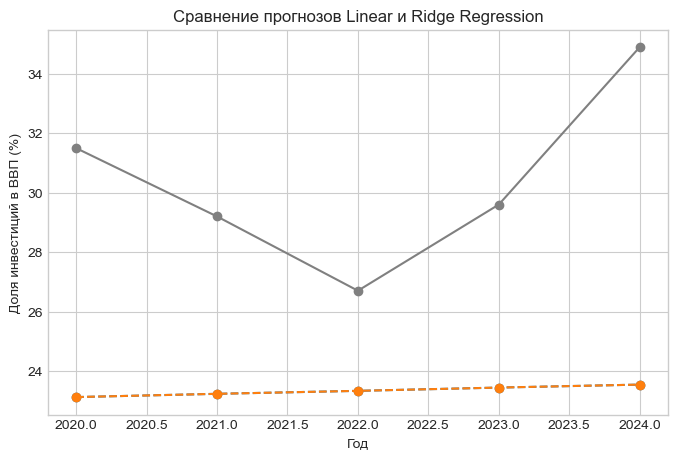

In [17]:
plt.figure(figsize=(8,5))

# Прогноз линейной регрессии
plt.plot(forecast_df['Year'], forecast_df['Predicted_Investment_share_GDP'], 
         marker='o', linestyle='--', label='Linear Regression')

# Прогноз Ridge-регрессии
plt.plot(ridge_df['Year'], ridge_df['Predicted_Investment_share_GDP'], 
         marker='o', linestyle='--', label='Ridge Regression')

# Фактические значения (для ориентира)
plt.plot(ridge_df['Year'], ridge_df['Previous_Investment_share_GDP'], 
         marker='o', color='gray', label='Фактические значения')

plt.title('Сравнение прогнозов Linear и Ridge Regression')
plt.xlabel('Год')
plt.ylabel('Доля инвестиций в ВВП (%)')
plt.show()


2 - модель :
Lasso


In [18]:
from sklearn.linear_model import Lasso

# Создаем модель Lasso (с небольшим штрафом)
model_lasso = Lasso(alpha=0.1)

# Обучаем модель
model_lasso.fit(X_train, y_train)

# Делаем прогноз
y_pred_lasso = model_lasso.predict(X_test)

# Создаём DataFrame для результатов
lasso_df = pd.DataFrame({
    'Year': X_test.values.flatten(),
    'Previous_Investment_share_GDP': y_test.values.flatten(),
    'Predicted_Investment_share_GDP': y_pred_lasso.round(2)
})

lasso_df


,Year,Previous_Investment_share_GDP,Predicted_Investment_share_GDP
0,2020,31.50,23.09
1,2021,29.20,23.19
2,2022,26.70,23.29
3,2023,29.60,23.40
4,2024,34.90,23.50


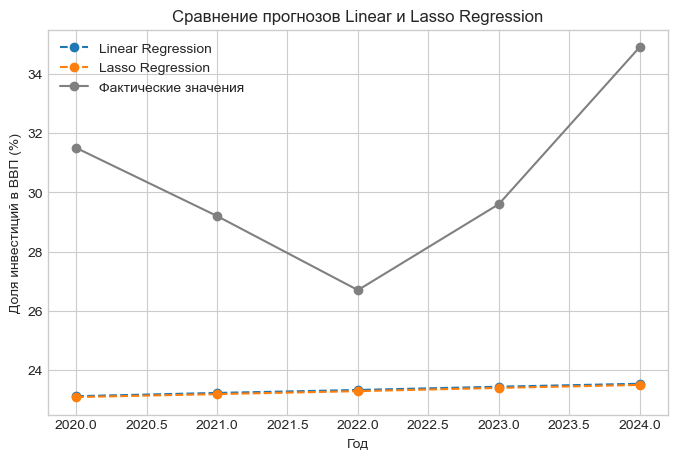

In [20]:
plt.figure(figsize=(8,5))

# Прогноз Linear Regression
plt.plot(
    forecast_df['Year'],
    forecast_df['Predicted_Investment_share_GDP'],
    marker='o',
    linestyle='--',
    label='Linear Regression'
)

# Прогноз Lasso Regression
plt.plot(
    lasso_df['Year'],
    lasso_df['Predicted_Investment_share_GDP'],
    marker='o',
    linestyle='--',
    label='Lasso Regression'
)

# Фактические значения
plt.plot(
    lasso_df['Year'],
    lasso_df['Previous_Investment_share_GDP'],
    marker='o',
    color='gray',
    label='Фактические значения'
)

plt.title('Сравнение прогнозов Linear и Lasso Regression')
plt.xlabel('Год')
plt.ylabel('Доля инвестиций в ВВП (%)')

plt.legend()
plt.grid(True)
plt.show()

3.3.3 Random Forest (как ML-модель)


In [19]:
from sklearn.ensemble import RandomForestRegressor

# Создаем модель случайного леса
model_rf = RandomForestRegressor(
    n_estimators=200,      # количество деревьев
    random_state=42
)

# Обучаем на train
model_rf.fit(X_train, y_train)

# Прогноз на test
y_pred_rf = model_rf.predict(X_test)

# Собираем результат в таблицу
rf_df = pd.DataFrame({
    'Year': X_test.values.flatten(),
    'Previous_Investment_share_GDP': y_test.values.flatten(),
    'Predicted_Investment_share_GDP': y_pred_rf.round(2)
})

rf_df


,Year,Previous_Investment_share_GDP,Predicted_Investment_share_GDP
0,2020,31.50,29.77
1,2021,29.20,29.77
2,2022,26.70,29.77
3,2023,29.60,29.77
4,2024,34.90,29.77


График леса

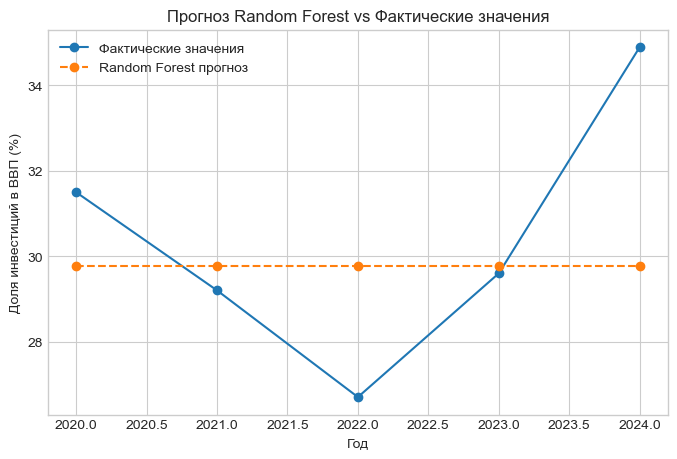

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Фактические значения
plt.plot(rf_df['Year'], 
         rf_df['Previous_Investment_share_GDP'], 
         marker='o', label='Фактические значения')

# Прогноз Random Forest
plt.plot(rf_df['Year'], 
         rf_df['Predicted_Investment_share_GDP'], 
         marker='o', linestyle='--', label='Random Forest прогноз')

plt.title('Прогноз Random Forest vs Фактические значения')
plt.xlabel('Год')
plt.ylabel('Доля инвестиций в ВВП (%)')
plt.grid(True)
plt.legend()
plt.show()
